![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)


# **📚 Aufgabensammlung: Kategorische Features transformieren**
## 🔹 **1. One-Hot-Encoding**
Erstelle einen DataFrame mit einer Spalte `"Tier"` mit den folgenden Werten:
- "Hund", "Katze", "Vogel", "Katze", "Hund", "Vogel", "Hund"

**Aufgabe:**  
- Verwende **One-Hot-Encoding**, um `"Tier"` in binäre Spalten umzuwandeln.
- Wie viele Spalten entstehen durch die Transformation?

In [3]:
import pandas as pd
import numpy as np
# Erstellen des DataFrames mit der Spalte "Tier"
df = pd.DataFrame({"Tier": ["Hund", "Katze", "Vogel", "Katze", "Hund", "Vogel", "Hund"]})

# One-Hot-Encoding mit pandas
df_encoded = pd.get_dummies(df, columns=["Tier"], prefix="Tier")

# Ergebnis anzeigen
print(df_encoded)


   Tier_Hund  Tier_Katze  Tier_Vogel
0       True       False       False
1      False        True       False
2      False       False        True
3      False        True       False
4       True       False       False
5      False       False        True
6       True       False       False


---

## 🔹 **2. Label-Encoding**
Erstelle einen DataFrame mit einer Spalte `"Bewertung"` mit den Werten:
- "Sehr schlecht", "Schlecht", "Neutral", "Gut", "Sehr gut"

**Aufgabe:**  
- Wandle die Werte in numerische Werte um, wobei **"Sehr schlecht" = 0** und **"Sehr gut" = 4** sein soll.
- Warum wäre hier One-Hot-Encoding keine gute Wahl?

In [5]:
from sklearn.preprocessing import LabelEncoder

# Erstellen des DataFrames mit der Spalte "Bewertung"
df = pd.DataFrame({"Bewertung": ["Sehr schlecht", "Schlecht", "Neutral", "Gut", "Sehr gut", "Schlecht", "Neutral"]})

# Manuelle Reihenfolge definieren (logische Reihenfolge von schlecht zu gut)
bewertung_order = ["Sehr schlecht", "Schlecht", "Neutral", "Gut", "Sehr gut"]

# Label-Encoding basierend auf der definierten Reihenfolge
df["Bewertung_encoded"] = df["Bewertung"].apply(lambda x: bewertung_order.index(x))

# Ergebnis anzeigen
print(df)


       Bewertung  Bewertung_encoded
0  Sehr schlecht                  0
1       Schlecht                  1
2        Neutral                  2
3            Gut                  3
4       Sehr gut                  4
5       Schlecht                  1
6        Neutral                  2


One-Hot-Encoding wäre hier nicht gut, da die Werte eine Reihenfolge haben.

---

## 🔹 **3. Frequency-Encoding**
Erstelle einen DataFrame mit einer Spalte `"Produktkategorie"` mit den folgenden Werten:
- "Elektronik", "Mode", "Elektronik", "Möbel", "Mode", "Elektronik", "Möbel", "Mode", "Mode"

**Aufgabe:**  
- Berechne, wie oft jede Produktkategorie vorkommt, und ersetze die Werte durch ihre relative Häufigkeit.
- Welchen Vorteil hat Frequency-Encoding gegenüber One-Hot-Encoding?

In [8]:
# Erstellen des DataFrames mit der Spalte "Produktkategorie"
df = pd.DataFrame({"Produktkategorie": ["Elektronik", "Mode", "Elektronik", "Möbel", "Mode", 
                                        "Elektronik", "Möbel", "Mode", "Mode"]})

# Berechnung der Häufigkeit jeder Kategorie
freq_encoding = df["Produktkategorie"].value_counts(normalize=True)

# Ersetzen der Werte durch ihre relative Häufigkeit
df["Produkt_encoded"] = df["Produktkategorie"].map(freq_encoding)

# Ergebnis anzeigen
print(df)


  Produktkategorie  Produkt_encoded
0       Elektronik         0.333333
1             Mode         0.444444
2       Elektronik         0.333333
3            Möbel         0.222222
4             Mode         0.444444
5       Elektronik         0.333333
6            Möbel         0.222222
7             Mode         0.444444
8             Mode         0.444444


Vorteil: Spart Platz im Vergleich zu One-Hot-Encoding.


---

## 🔹 **4. Target-Encoding**
Gegeben ist folgender DataFrame:

| Stadt     | Hauspreis (€) |
|-----------|-------------|
| Berlin    | 450000      |
| Hamburg   | 500000      |
| Berlin    | 470000      |
| München   | 700000      |
| Hamburg   | 530000      |
| München   | 720000      |
| Berlin    | 460000      |

**Aufgabe:**  
- Wandle die `"Stadt"`-Spalte mit **Target-Encoding** um, indem du für jede Stadt den **durchschnittlichen Hauspreis** berechnest.
- Warum kann Target-Encoding zu **Datenleckage (Data Leakage)** führen?

In [11]:
# Erstellen des DataFrames mit "Stadt" und "Hauspreis"
df = pd.DataFrame({
    "Stadt": ["Berlin", "Hamburg", "Berlin", "München", "Hamburg", "München", "Berlin"],
    "Hauspreis": [450000, 500000, 470000, 700000, 530000, 720000, 460000]
})

# Berechnung des durchschnittlichen Hauspreises pro Stadt
target_encoding = df.groupby("Stadt")["Hauspreis"].mean()

# Ersetzen der Städte durch ihren Durchschnittspreis
df["Stadt_encoded"] = df["Stadt"].map(target_encoding)

# Ergebnis anzeigen
print(df)


     Stadt  Hauspreis  Stadt_encoded
0   Berlin     450000       460000.0
1  Hamburg     500000       515000.0
2   Berlin     470000       460000.0
3  München     700000       710000.0
4  Hamburg     530000       515000.0
5  München     720000       710000.0
6   Berlin     460000       460000.0


⚠ Datenleckage-Risiko: Wenn das Modell auf dem gesamten Datensatz trainiert, kennt es schon die Hauspreise aus der Zukunft!

---

## 🔹 **5. Vergleich der Methoden**
Angenommen, du hast eine Spalte `"Sportart"` mit den Werten:
- "Fußball", "Basketball", "Tennis", "Schwimmen", "Fußball", "Tennis", "Fußball", "Basketball"

**Aufgabe:**  
- Wende **One-Hot-Encoding, Label-Encoding und Frequency-Encoding** an.
- Erstelle einen kurzen Vergleich: Wann ist welche Methode sinnvoll?

In [14]:
from sklearn.preprocessing import LabelEncoder

# Erstellen des DataFrames mit der Spalte "Sportart"
df = pd.DataFrame({"Sportart": ["Fußball", "Basketball", "Tennis", "Schwimmen", 
                                "Fußball", "Tennis", "Fußball", "Basketball"]})

# 1️⃣ One-Hot-Encoding
df_onehot = pd.get_dummies(df, columns=["Sportart"])

# 2️⃣ Label-Encoding
encoder = LabelEncoder()
df["Sportart_Label"] = encoder.fit_transform(df["Sportart"])

# 3️⃣ Frequency-Encoding
freq_encoding = df["Sportart"].value_counts(normalize=True)
df["Sportart_Freq"] = df["Sportart"].map(freq_encoding)

# Ergebnis anzeigen
display(df)
display(df_onehot)

,Sportart,Sportart_Label,Sportart_Freq
0,Fußball,1,0.375
1,Basketball,0,0.250
2,Tennis,3,0.250
3,Schwimmen,2,0.125
4,Fußball,1,0.375
5,Tennis,3,0.250
6,Fußball,1,0.375
7,Basketball,0,0.250


,Sportart_Basketball,Sportart_Fußball,Sportart_Schwimmen,Sportart_Tennis
0,False,True,False,False
1,True,False,False,False
2,False,False,False,True
3,False,False,True,False
4,False,True,False,False
5,False,False,False,True
6,False,True,False,False
7,True,False,False,False



**📌 Vergleich:**
| Methode | Vorteil | Nachteil |
|---------|---------|----------|
| **One-Hot-Encoding** | Keine Reihenfolge-Probleme | Viele Spalten |
| **Label-Encoding** | Einfach und platzsparend | Reihenfolge könnte falsch interpretiert werden |
| **Frequency-Encoding** | Spart Platz, erhält Kategorien | Kann für unbekannte Werte problematisch sein |


# Numerische Features transformieren

## **🔹 1. Binning (Einteilen in Kategorien)**
Gegeben ist ein Datensatz mit Altersangaben:

In [17]:

# Beispiel-Daten: Altersangaben
df = pd.DataFrame({"Alter": [5, 18, 25, 40, 55, 65, 80]})
display(df)

,Alter
0,5
1,18
2,25
3,40
4,55
5,65
6,80


**📝 Aufgabe:**  
- Erstelle eine neue Spalte `"Altersgruppe"`, in der die Alterswerte in folgende Gruppen eingeteilt werden:  
  - `0–18 Jahre`: **"Kind"**  
  - `19–35 Jahre`: **"Jung"**  
  - `36–50 Jahre`: **"Mittelalt"**  
  - `51–65 Jahre`: **"Alt"**  
  - `66+ Jahre`: **"Senior"**  
- Nutze entweder `pd.cut()` oder eine eigene `apply()`-Funktion.

In [19]:
# Altersgruppen mit pd.cut() definieren
bins = [0, 18, 35, 50, 65, 100]  # Altersgrenzen
labels = ["Kind", "Jung", "Mittelalt", "Alt", "Senior"]  # Kategorien
df["Altersgruppe"] = pd.cut(df["Alter"], bins=bins, labels=labels, right=True)

# Ergebnis anzeigen
print(df)


   Alter Altersgruppe
0      5         Kind
1     18         Kind
2     25         Jung
3     40    Mittelalt
4     55          Alt
5     65          Alt
6     80       Senior


---

## **🔹 2. Interaktionsvariablen (Multiplikation)**
Gegeben ist ein Datensatz mit **Immobilienpreisen**:

In [21]:

# Beispiel-Daten: Quadratmeterpreis und Wohnfläche
df = pd.DataFrame({
    "Preis_pro_m2": [4000, 5000, 3000, 4500, 5200],  # €/m²
    "Wohnfläche_m2": [50, 80, 100, 60, 75]  # m²
})
display(df)

,Preis_pro_m2,Wohnfläche_m2
0,4000,50
1,5000,80
2,3000,100
3,4500,60
4,5200,75


**📝 Aufgabe:**  
- Erstelle eine neue Spalte `"Gesamtpreis"`, die den Gesamtwert einer Immobilie berechnet:  
  **Formel: Gesamtpreis = Wohnfläche × Preis pro m²**  
- Erweitere das Modell, indem du eine weitere Interaktionsvariable `"Preis_mit_Steuer"` berechnest,  
  falls eine **Grundsteuer von 5%** auf den Preis erhoben wird.

In [23]:
import pandas as pd

# Beispiel-Daten: Quadratmeterpreis und Wohnfläche
df = pd.DataFrame({
    "Preis_pro_m2": [4000, 5000, 3000, 4500, 5200],  # €/m²
    "Wohnfläche_m2": [50, 80, 100, 60, 75]  # m²
})

# Gesamtpreis berechnen: Wohnfläche * Preis pro m²
df["Gesamtpreis"] = df["Wohnfläche_m2"] * df["Preis_pro_m2"]

# Preis mit 5% Steuer berechnen
df["Preis_mit_Steuer"] = df["Gesamtpreis"] * 1.05

# Ergebnis anzeigen
print(df)


   Preis_pro_m2  Wohnfläche_m2  Gesamtpreis  Preis_mit_Steuer
0          4000             50       200000          210000.0
1          5000             80       400000          420000.0
2          3000            100       300000          315000.0
3          4500             60       270000          283500.0
4          5200             75       390000          409500.0


---

## **🔹 3. Log-Transformation**
Gegeben ist ein Datensatz mit **Jahreseinkommen**:

In [25]:
# Beispiel-Daten: Einkommen
df = pd.DataFrame({"Einkommen": [25000, 30000, 1000000, 50000, 100000, 150000, 200000, 15000, 10000, 800000]})
display(df)

,Einkommen
0,25000
1,30000
2,1000000
3,50000
4,100000
5,150000
6,200000
7,15000
8,10000
9,800000


**📝 Aufgabe:**  
- Wende eine **Log-Transformation** auf die Spalte `"Einkommen"` an, um eine neue Spalte `"Log_Einkommen"` zu erzeugen.
- Erstelle ein **Histogramm** der Werte **vor und nach der Transformation**, um zu sehen, wie sich die Verteilung verändert.
- Erkläre, warum Log-Transformation für Einkommen oft sinnvoll ist.

---



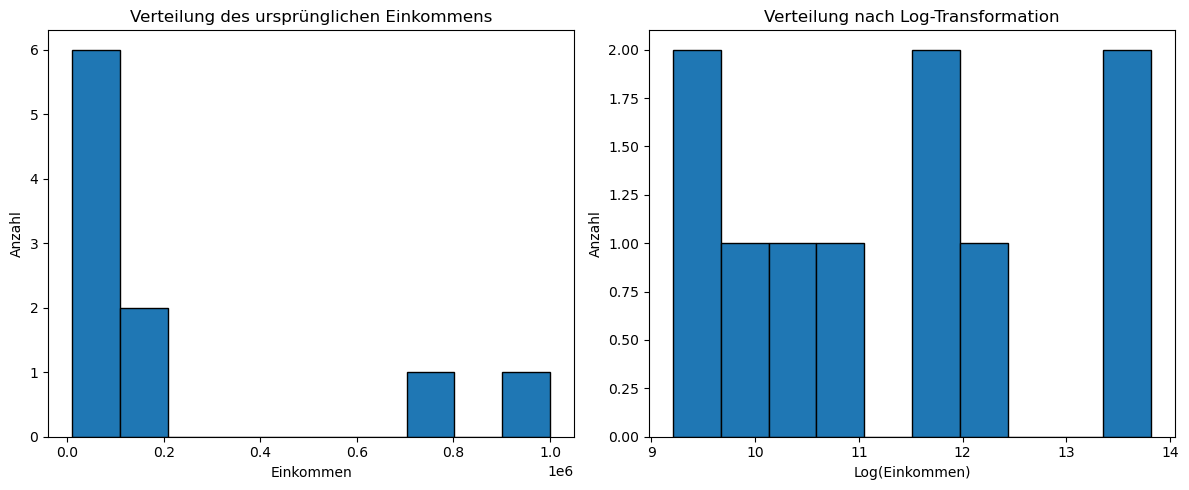

   Einkommen  Log_Einkommen
0      25000      10.126631
1      30000      10.308953
2    1000000      13.815511
3      50000      10.819778
4     100000      11.512925
5     150000      11.918391
6     200000      12.206073
7      15000       9.615805
8      10000       9.210340
9     800000      13.592367


In [27]:
import matplotlib.pyplot as plt


# Log-Transformation
df["Log_Einkommen"] = np.log(df["Einkommen"])

# Histogramme für Vergleich
plt.figure(figsize=(12, 5))

# Originale Einkommensverteilung
plt.subplot(1, 2, 1)
plt.hist(df["Einkommen"], bins=10, edgecolor="black")
plt.xlabel("Einkommen")
plt.ylabel("Anzahl")
plt.title("Verteilung des ursprünglichen Einkommens")

# Log-transformierte Einkommensverteilung
plt.subplot(1, 2, 2)
plt.hist(df["Log_Einkommen"], bins=10, edgecolor="black")
plt.xlabel("Log(Einkommen)")
plt.ylabel("Anzahl")
plt.title("Verteilung nach Log-Transformation")

plt.tight_layout()
plt.show()

# Ergebnis anzeigen
print(df)



**📌 Erklärung:**
- Einkommen ist oft **rechtsschief verteilt** (einige Leute verdienen extrem viel).
- Die **Log-Transformation glättet diese Unterschiede** und macht die Verteilung **symmetrischer**.

**🔍 Ergebnis (Vergleich der Verteilungen):**
- **Links:** Originale Einkommensverteilung → Sehr verzerrt!  
- **Rechts:** Nach der Log-Transformation → Gleichmäßiger, eher normalverteilt.

---

## **🎯 Fazit**
Diese Methoden helfen dabei, **numerische Daten besser zu strukturieren und für Machine Learning nutzbar zu machen**:

1️⃣ **Binning** → Macht kontinuierliche Werte vergleichbar (z. B. Altersgruppen).  
2️⃣ **Interaktionsvariablen** → Kombiniert bestehende Features, um neue Erkenntnisse zu gewinnen (z. B. Gesamtpreis).  
3️⃣ **Log-Transformation** → Reduziert Verzerrungen und macht die Verteilung normaler (z. B. Einkommen).  

